# 📦 Olist E-commerce — Exploratory Data Analysis
### From the Gold Mart to a board-room decision

**Author:** HoongJun · **Module 5 (Analytics)** · **Data:** `sctp-team2-project2-elt.olist_gold_mart_prod`

---

## Executive summary — read this first

> **The company is *buying* growth it should be *earning*.** The binding constraint
> on profitable growth is the **repeat-purchase rate**, and the single biggest
> controllable lever on it is **delivery experience**.

Three executives each see one face of the same elephant:

| Who | What they see | What they conclude | Why that's the wrong fix |
| --- | --- | --- | --- |
| **CEO** | GMV grows, but marketing spend climbs to sustain it; margins soft | "We're working harder to grow" | The leak is *retention*, not pricing or competition |
| **CMO** | Re-engagement underperforms, churn ugly | "Our brand isn't sticky → spend more on loyalty" | The churn cause is operational, not a comms problem |
| **CTO** | Delivery complaints, low review scores | "Logistics cost to optimise" (noise) | Those late deliveries *are* the revenue leak |

**What the data shows (validated in this notebook):**

1. **Retention is the constraint** — only **~3.5%** of orders are repeat purchases
   (96,096 customers → 99,441 orders). Growth ≈ pure new-customer acquisition.
2. **Delivery's tail is toxic** — ~**8%** of delivered orders arrive *late*.
3. **The smoking gun** — on-time orders average **4.3★**; late orders average
   **2.6★**, and **54%** of late-delivery customers leave a 1–2★ review.

**The chain:** *late delivery → low review → customer never returns → low repeat
rate → rising acquisition spend & soft margins.* The cause lives in the **CTO's**
domain, surfaces as the **CMO's** retention problem, and shows up in the **CEO's**
P&L. **Fixing delivery reliability is cheaper than buying replacement growth.**

---

## 1. How to read this notebook (and a 60-second pandas/seaborn primer)

This notebook is also a **learning artifact**. Every analysis step has three parts:

1. **🎯 Purpose** — *why* we run it (the business question).
2. **🧮 The code** — *what* it does, with comments on each pandas/seaborn idiom.
3. **🔍 Reading the result** — *how* to interpret the numbers/chart and what it implies.

**Vocabulary you'll see a lot:**

| Term | Plain meaning |
| --- | --- |
| `DataFrame` (`df`) | A table in memory — rows × named columns. Think "Excel sheet in Python." |
| `df.groupby('x')['y'].mean()` | "For each value of column *x*, average column *y*." (a pivot/summary) |
| `df['col']` | One column (a `Series`). `df[['a','b']]` selects several columns. |
| `df[df['x'] > 5]` | **Filtering** — keep only rows where the condition is True. |
| `.value_counts()` | Frequency table — how many rows fall in each category. |
| `sns.barplot(...)` | Seaborn = matplotlib with nicer defaults. `sns.*plot` draws the chart. |

You do **not** need to memorise these — the comments re-explain them in context.

### 1.1 Setup — connect to BigQuery

We read **gold-mart** tables (the trusted, modelled layer) directly into pandas.

**Authentication:** we use a **service-account keyfile** stored in `../secrets/`. To
run elsewhere, point `GOOGLE_APPLICATION_CREDENTIALS` at your own key — or, if no key
is found, the notebook falls back to your local `gcloud` login (ADC) so it still runs.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

warnings.filterwarnings("ignore")            # keep the notebook output clean for readers

# --- Visual defaults so every chart looks consistent & presentation-ready ---
sns.set_theme(style="whitegrid", palette="deep")   # whitegrid = light gridlines, easy to read
plt.rcParams["figure.figsize"] = (10, 5)           # default chart size (width, height in inches)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110                   # crispness on screen
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")  # 1,234.50 instead of 1234.4999

PROJECT = "sctp-team2-project2-elt"
GOLD    = f"{PROJECT}.olist_gold_mart_prod"   # the gold mart (our contract)
SNAP    = f"{PROJECT}.snapshots"              # reviews_dbt_scd_snapshot lives here (has order_id)

# --- Build a BigQuery client using a service-account keyfile. ---
# Override the location anytime via:  export GOOGLE_APPLICATION_CREDENTIALS=/path/to/key.json
# Default path is relative to this notebook (notebooks/eda/) -> ../secrets/<key>.json
KEYFILE = os.environ.get(
    "GOOGLE_APPLICATION_CREDENTIALS",
    os.path.join("..", "secrets", "sctp-team2-project2-elt-ROTATED-dbcb3cd092f4.json"),
)

def make_client():
    # Authenticate with the service-account keyfile (the project's chosen method)...
    if os.path.exists(KEYFILE):
        try:
            from google.oauth2 import service_account
            creds = service_account.Credentials.from_service_account_file(KEYFILE)
            client = bigquery.Client(credentials=creds, project=PROJECT)
            client.query("SELECT 1").result()          # smoke-test the credentials
            print(f"✅ Authenticated with service-account keyfile: {KEYFILE}")
            return client
        except Exception as e:
            print(f"⚠️  Keyfile present but unusable ({str(e)[:60]}...). Falling back to gcloud ADC.")
    # ...fall back to Application Default Credentials (your `gcloud auth` login) if no key.
    client = bigquery.Client(project=PROJECT)
    client.query("SELECT 1").result()
    print("✅ Authenticated with gcloud Application Default Credentials (ADC).")
    return client

client = make_client()

def q(sql: str) -> pd.DataFrame:
    # Run SQL on BigQuery and return the result as a pandas DataFrame.
    return client.query(sql).to_dataframe()

✅ Authenticated with service-account keyfile: ../secrets/sctp-team2-project2-elt-ROTATED-dbcb3cd092f4.json


## 2. Data overview — what are we working with?

**🎯 Purpose:** before *any* analysis, understand the **grain** (what one row means),
the **size**, the **time span**, and where data is **missing**. Skipping this is how
analysts produce confident-but-wrong charts.

**The gold mart (star schema):**

```
                 dim_customers ──┐
                 dim_products  ──┤
                 dim_sellers   ──┼──< fact_orders >── reviews_dbt_scd_snapshot
                                 │     (1 row per order ITEM)      (1 row per review)
```

`fact_orders` is at **order-item grain** — an order with 3 items = 3 rows. So to talk
about *orders* we must aggregate items up to the order. We do that next.

In [2]:
# Pull ONE row per ORDER by aggregating the item-grain fact up to order grain.
# SUM(price) = order GMV; COUNT(*) = items in the order. ANY_VALUE picks the order-level
# attributes (identical across an order's items, so "any value" is safe).
sql_orders = f'''
WITH order_items AS (
  SELECT
    id                                   AS order_id,
    ANY_VALUE(customer_id)               AS customer_id,
    ANY_VALUE(order_status)              AS order_status,
    ANY_VALUE(order_purchase_timestamp)  AS purchase_ts,
    ANY_VALUE(order_approved_at)         AS approved_ts,
    ANY_VALUE(order_delivered_customer_date) AS delivered_ts,
    ANY_VALUE(order_estimated_delivery_date) AS estimated_ts,
    ANY_VALUE(payment_value)             AS payment_value,
    SUM(price)                           AS order_gmv,      -- product revenue for the order
    SUM(freight_value)                   AS order_freight,  -- shipping charged
    COUNT(*)                             AS item_count
  FROM `{GOLD}.fact_orders`
  GROUP BY id
),
cur_reviews AS (   -- current review per order (snapshot rows still valid today)
  SELECT order_id, MAX(review_score) AS review_score
  FROM `{SNAP}.reviews_dbt_scd_snapshot`
  WHERE dbt_valid_to IS NULL AND order_id IS NOT NULL
  GROUP BY order_id
)
SELECT
  o.*,
  c.customer_unique_id,           -- the SAME person across multiple orders (key to retention!)
  c.customer_state,
  r.review_score
FROM order_items o
LEFT JOIN `{GOLD}.dim_customers` c ON o.customer_id = c.id
LEFT JOIN cur_reviews            r ON o.order_id    = r.order_id
'''
orders = q(sql_orders)

# Make timestamps real datetimes so we can do date maths (subtract, resample by month).
for col in ["purchase_ts", "approved_ts", "delivered_ts", "estimated_ts"]:
    orders[col] = pd.to_datetime(orders[col])

print(f"orders table: {orders.shape[0]:,} rows  ×  {orders.shape[1]} columns")
orders.head(3)

orders table: 99,441 rows  ×  14 columns


,order_id,customer_id,order_status,purchase_ts,approved_ts,delivered_ts,estimated_ts,payment_value,order_gmv,order_freight,item_count,customer_unique_id,customer_state,review_score
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19+00:00,2016-10-07 13:18:03+00:00,NaT,2016-10-20 00:00:00+00:00,136.23,72.89,63.34,2,b7d76e111c89f7ebf14761390f0f7d17,RR,1
1,616766a13421c758b45c1912e9e4fedf,0a4e3807c23f486dea9adbdf8c73a70a,delivered,2017-03-08 23:21:32+00:00,2017-03-08 23:21:32+00:00,2017-03-28 16:14:54+00:00,2017-04-06 00:00:00+00:00,134.96,109.99,24.97,1,fc4249eb9b18bed24ff89e4a34eafa69,SE,1
2,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,delivered,2017-03-08 22:47:40+00:00,2017-03-08 22:47:40+00:00,2017-09-19 14:00:04+00:00,2017-04-06 00:00:00+00:00,457.65,429.90,27.75,1,3c2564d42f7ddd8b7576f0dd9cb1b4c5,SE,1


**🧮 What just happened:** `orders.shape` returns `(rows, columns)`. `.head(3)` shows
the first 3 rows so we can eyeball the structure. One row = one **order**.

In [3]:
# .info() = the column inventory: name, count of NON-null values, and data type (dtype).
# Where "Non-Null Count" < total rows, that column has MISSING values.
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   order_id            99441 non-null  object             
 1   customer_id         99441 non-null  object             
 2   order_status        99441 non-null  object             
 3   purchase_ts         99441 non-null  datetime64[us, UTC]
 4   approved_ts         99281 non-null  datetime64[us, UTC]
 5   delivered_ts        96476 non-null  datetime64[us, UTC]
 6   estimated_ts        99441 non-null  datetime64[us, UTC]
 7   payment_value       99440 non-null  float64            
 8   order_gmv           98666 non-null  float64            
 9   order_freight       98666 non-null  float64            
 10  item_count          99441 non-null  Int64              
 11  customer_unique_id  99441 non-null  object             
 12  customer_state      99441 non-nu

**🔍 Reading `.info()`:** look at the gaps. `delivered_ts` is null for orders that
were never delivered (cancelled/in-transit). `review_score` is null for orders with
no review. These nulls are *meaningful*, not errors — we'll handle each explicitly.

In [4]:
# .describe() = quick statistics for numeric columns: count, mean, std, min, quartiles, max.
# It's the fastest way to spot skew and outliers.
orders[["order_gmv", "order_freight", "payment_value", "item_count", "review_score"]].describe()

,order_gmv,order_freight,payment_value,item_count,review_score
count,"98,666.00","98,666.00","99,440.00","99,441.00","98,131.00"
mean,137.75,22.82,158.33,1.14,4.09
std,210.65,21.65,220.01,0.54,1.34
min,0.85,0.00,0.00,1.00,1.00
25%,45.90,13.85,60.07,1.00,4.00
50%,86.90,17.17,103.34,1.00,5.00
75%,149.90,24.04,175.09,1.00,5.00
max,"13,440.00","1,794.96","13,664.08",21.00,5.00


**🔍 Reading `.describe()`:**
- **mean ≫ median (50%)** for `order_gmv` ⇒ a *right-skewed* spend distribution: most
  orders are small, a few are large. (So we'll prefer **medians** and **sums**, not means, for money.)
- `item_count` is mostly 1 — Olist is a **single-item, one-shot** marketplace, which
  foreshadows the retention problem.
- The date span (printed below) tells us how much history we have.

In [5]:
span = orders["purchase_ts"].agg(["min", "max"])
print(f"Order history: {span['min'].date()}  →  {span['max'].date()}")

# Missingness as a % per column — a standard data-quality check.
miss = orders.isna().mean().mul(100).round(1).sort_values(ascending=False)
print("\nMissing values (% of rows):")
print(miss[miss > 0].to_string())

Order history: 2016-09-04  →  2018-10-17

Missing values (% of rows):
delivered_ts    3.00
review_score    1.30
order_gmv       0.80
order_freight   0.80
approved_ts     0.20


## 3. Data quality — what do we trust, and what do we exclude?

**🎯 Purpose:** decide which rows are valid for each question. For delivery analysis
we only want orders that were actually **delivered** (others have no delivery date).

,orders,pct
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


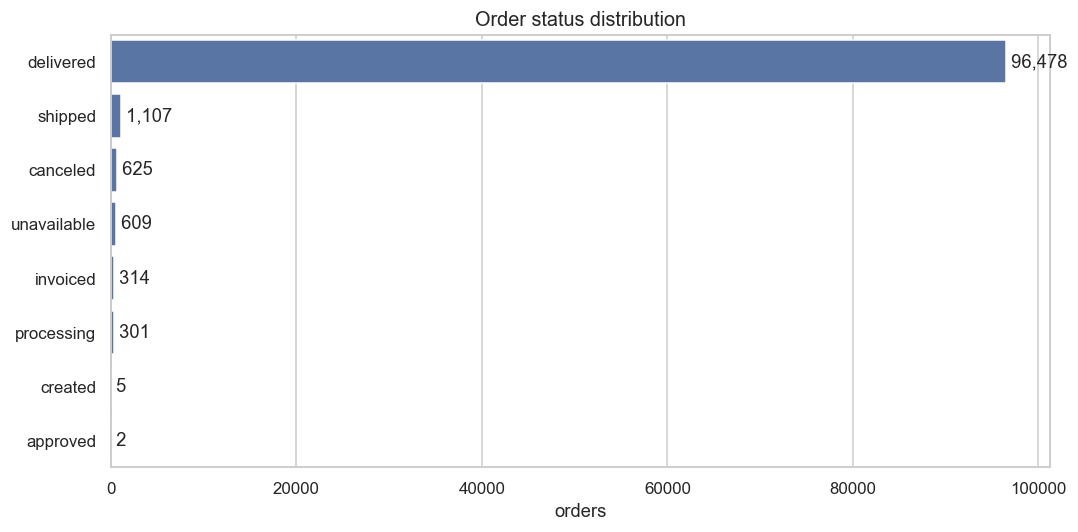

In [6]:
# value_counts() = a frequency table. normalize=True turns counts into proportions.
status = orders["order_status"].value_counts()
status_pct = orders["order_status"].value_counts(normalize=True).mul(100).round(2)
status_tbl = pd.concat([status, status_pct], axis=1, keys=["orders", "pct"])
display(status_tbl)

ax = sns.barplot(x=status.values, y=status.index, color="#4C72B0")
ax.set(title="Order status distribution", xlabel="orders", ylabel="")
for i, v in enumerate(status.values):                 # annotate each bar with its value
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()

**🔍 Reading it:** the overwhelming majority are **`delivered`** — good, our delivery
and review analyses rest on a large, clean base. The small `canceled`/`unavailable`
slices are excluded from delivery timing (they have no delivery date by definition).

## 4. GMV trend — is the CEO right that we're growing?

**🎯 Purpose:** quantify the growth the CEO *feels*. We sum order GMV by **calendar
month** and plot the trend.

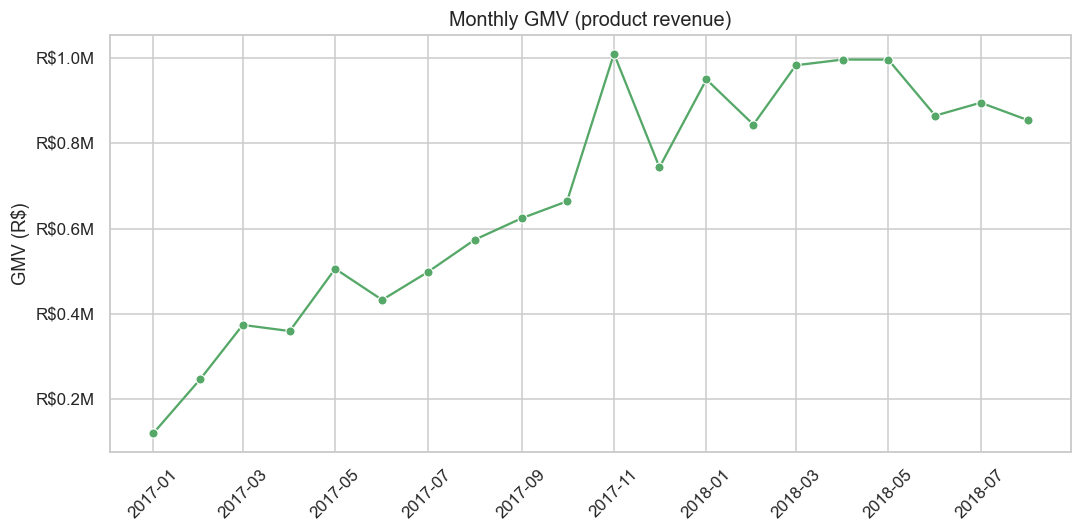

GMV grew ~610% from 2017-01-01 to 2018-08-01.


In [7]:
# Keep orders with a real purchase date and GMV. Then bucket each order into its month.
g = orders.dropna(subset=["purchase_ts", "order_gmv"]).copy()
g["month"] = g["purchase_ts"].dt.to_period("M").dt.to_timestamp()   # 2017-05-14 -> 2017-05-01

# groupby('month') then sum GMV = monthly revenue. (Trim the last partial month for fairness.)
monthly = g.groupby("month")["order_gmv"].sum()
monthly = monthly[(monthly.index >= "2017-01-01") & (monthly.index <= "2018-08-01")]

ax = sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="#55A868")
ax.set(title="Monthly GMV (product revenue)", xlabel="", ylabel="GMV (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R${v/1e6:.1f}M"))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

growth = (monthly.iloc[-1] / monthly.iloc[0] - 1) * 100
print(f"GMV grew ~{growth:,.0f}% from {monthly.index[0].date()} to {monthly.index[-1].date()}.")

**🔍 Reading it:** GMV climbs strongly through 2017 then plateaus into 2018. The CEO's
instinct is correct — *the top line grows*. The question the rest of the notebook
answers is **at what cost**: is this growth coming from keeping customers, or from
constantly buying new ones?

## 5. Retention — the binding constraint

**🎯 Purpose:** test the core hypothesis. Growth is healthy only if customers come
**back**. We use `customer_unique_id` (the same human across orders) to measure the
**repeat-purchase rate**.

In [8]:
# How many orders has each unique customer placed?
orders_per_customer = orders.groupby("customer_unique_id")["order_id"].nunique()

n_customers   = orders_per_customer.size
n_orders      = int(orders_per_customer.sum())
n_repeaters   = int((orders_per_customer > 1).sum())          # customers with 2+ orders
repeat_rate   = n_repeaters / n_customers * 100               # share of customers who returned
repeat_orders = (n_orders - n_customers) / n_orders * 100     # share of orders that are repeats

print(f"Unique customers      : {n_customers:,}")
print(f"Total orders          : {n_orders:,}")
print(f"Customers who repeated: {n_repeaters:,}  ({repeat_rate:.1f}% of customers)")
print(f"Repeat ORDERS         : {repeat_orders:.1f}% of all orders")

Unique customers      : 96,096
Total orders          : 99,441
Customers who repeated: 2,997  (3.1% of customers)
Repeat ORDERS         : 3.4% of all orders


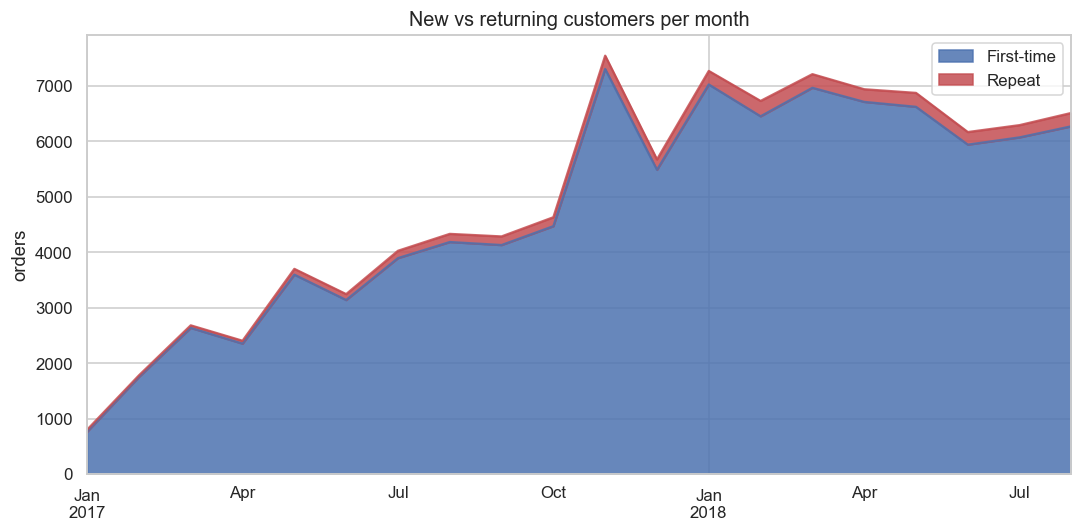

In [9]:
# Split EVERY order into the customer's "first ever" vs a "repeat", by purchase time.
o = orders.dropna(subset=["purchase_ts"]).copy()
o["order_rank"] = o.groupby("customer_unique_id")["purchase_ts"].rank(method="first")
o["kind"] = np.where(o["order_rank"] == 1, "First-time", "Repeat")
o["month"] = o["purchase_ts"].dt.to_period("M").dt.to_timestamp()

mix = (o[o["month"].between("2017-01-01", "2018-08-01")]
       .groupby(["month", "kind"]).size().unstack(fill_value=0))

ax = mix.plot(kind="area", stacked=True, color=["#4C72B0", "#C44E52"], alpha=.85)
ax.set(title="New vs returning customers per month", xlabel="", ylabel="orders")
ax.legend(title="")
plt.tight_layout(); plt.show()

**🔍 Reading it:** the chart is almost entirely **first-time** customers — the thin red
band is repeats. **Only ~3–4% of customers ever come back.** This is the punchline:
the GMV growth in §4 is built on **acquisition, not loyalty**. That is *precisely*
the "working harder to grow / rising marketing spend" the CEO feels and the "churn"
the CMO sees. **Retention is the binding constraint.** Now — *why* don't they return?

## 6. Where revenue concentrates — top product categories

**🎯 Purpose:** know which categories drive GMV (so any delivery fix is prioritised
where the money is). Requires the **item grain** (category lives on the product).

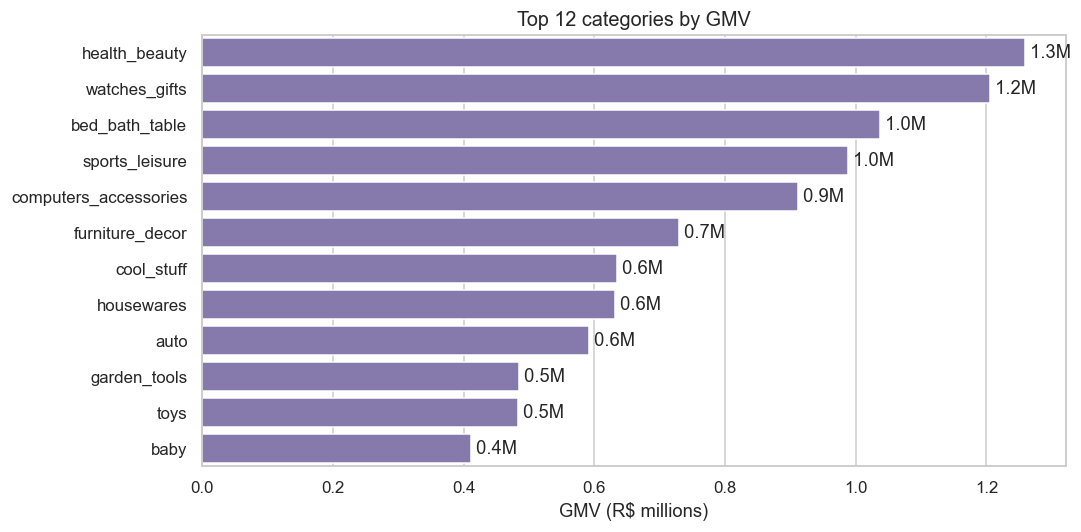

In [10]:
sql_items = f'''
SELECT f.id AS order_id, f.price, p.product_category
FROM `{GOLD}.fact_orders` f
LEFT JOIN `{GOLD}.dim_products` p ON f.product_id = p.id
WHERE f.price IS NOT NULL AND p.product_category IS NOT NULL
'''
items = q(sql_items)

top = (items.groupby("product_category")["price"].sum()
       .sort_values(ascending=False).head(12).div(1e6))   # R$ millions

ax = sns.barplot(x=top.values, y=top.index, color="#8172B3")
ax.set(title="Top 12 categories by GMV", xlabel="GMV (R$ millions)", ylabel="")
for i, v in enumerate(top.values):
    ax.text(v, i, f" {v:.1f}M", va="center")
plt.tight_layout(); plt.show()

**🔍 Reading it:** GMV is **concentrated** in a handful of categories (health/beauty,
watches, home, etc.). A delivery-reliability programme aimed at the top categories
and their lanes protects the most revenue per unit of effort.

## 7. Delivery performance — sizing the logistics problem

**🎯 Purpose:** measure how long delivery takes and how often we **miss the promised
date**. This is the CTO's domain — and, we'll argue, the company's biggest hidden lever.

Delivered orders analysed: 96,470
Median delivery time     : 10 days
LATE delivery rate       : 8.1% of delivered orders


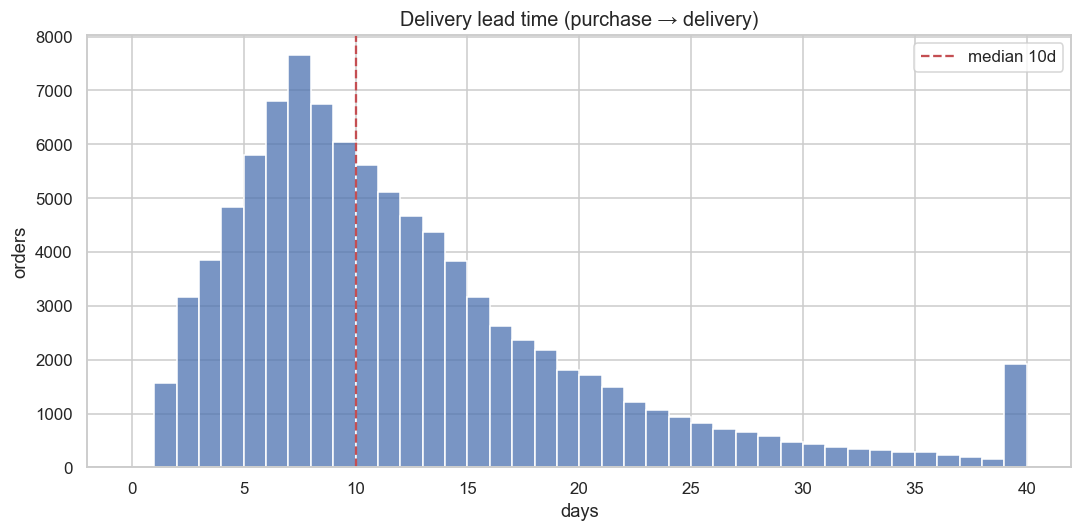

In [11]:
# Restrict to delivered orders with the dates we need.
d = orders[(orders["order_status"] == "delivered")
           & orders["delivered_ts"].notna()
           & orders["estimated_ts"].notna()
           & orders["purchase_ts"].notna()].copy()

# Date maths: lead time = days from purchase to delivery; a late order misses the promise.
d["lead_time_days"] = (d["delivered_ts"] - d["purchase_ts"]).dt.days
d["is_late"]        = d["delivered_ts"] > d["estimated_ts"]
d["delivery"]       = np.where(d["is_late"], "Late", "On-time")

late_rate = d["is_late"].mean() * 100
print(f"Delivered orders analysed: {len(d):,}")
print(f"Median delivery time     : {d['lead_time_days'].median():.0f} days")
print(f"LATE delivery rate       : {late_rate:.1f}% of delivered orders")

ax = sns.histplot(d["lead_time_days"].clip(upper=40), bins=40, color="#4C72B0")
ax.set(title="Delivery lead time (purchase → delivery)", xlabel="days", ylabel="orders")
ax.axvline(d["lead_time_days"].median(), color="#C44E52", ls="--",
           label=f"median {d['lead_time_days'].median():.0f}d")
ax.legend(); plt.tight_layout(); plt.show()

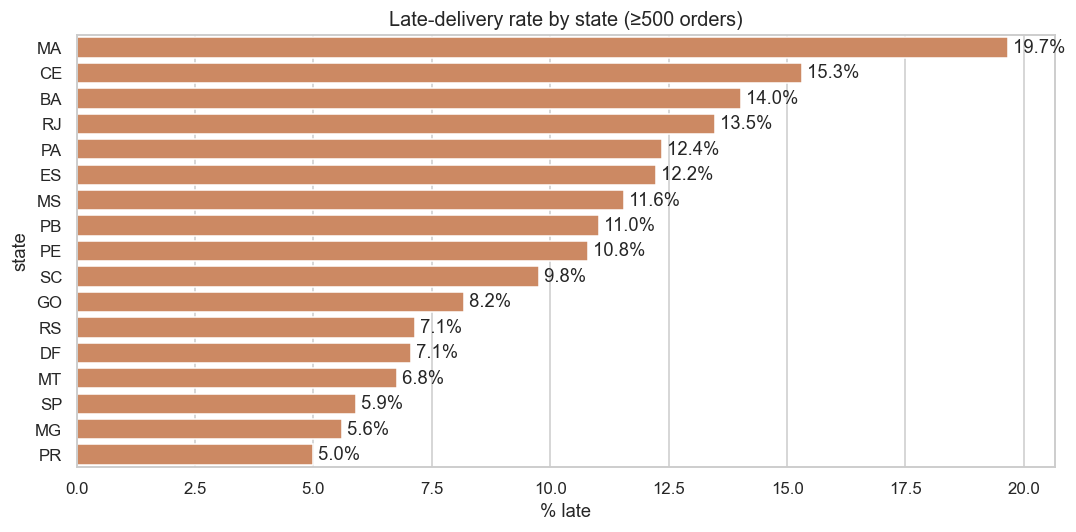

In [12]:
# Late rate by customer state — where is the problem worst? (states with >=500 orders)
by_state = (d.groupby("customer_state")
            .agg(orders=("order_id", "size"), late_rate=("is_late", "mean")))
by_state = by_state[by_state["orders"] >= 500].sort_values("late_rate", ascending=False)
by_state["late_rate"] *= 100

ax = sns.barplot(x=by_state["late_rate"], y=by_state.index, color="#DD8452")
ax.set(title="Late-delivery rate by state (≥500 orders)", xlabel="% late", ylabel="state")
for i, v in enumerate(by_state["late_rate"]):
    ax.text(v, i, f" {v:.1f}%", va="center")
plt.tight_layout(); plt.show()

**🔍 Reading it:** most deliveries arrive *before* the promised date (the median is
healthy), but a **meaningful tail (~8%) is late**, and lateness is **concentrated in
specific states** — i.e. it's a *targetable lane problem*, not random. That matters:
targeted fixes beat blanket spend. Next we prove these late orders are *expensive*.

## 8. Reviews & the smoking gun — late delivery destroys satisfaction

**🎯 Purpose:** connect logistics to the customer's verdict. First the overall score
distribution, then the headline: **review score split by on-time vs late delivery.**

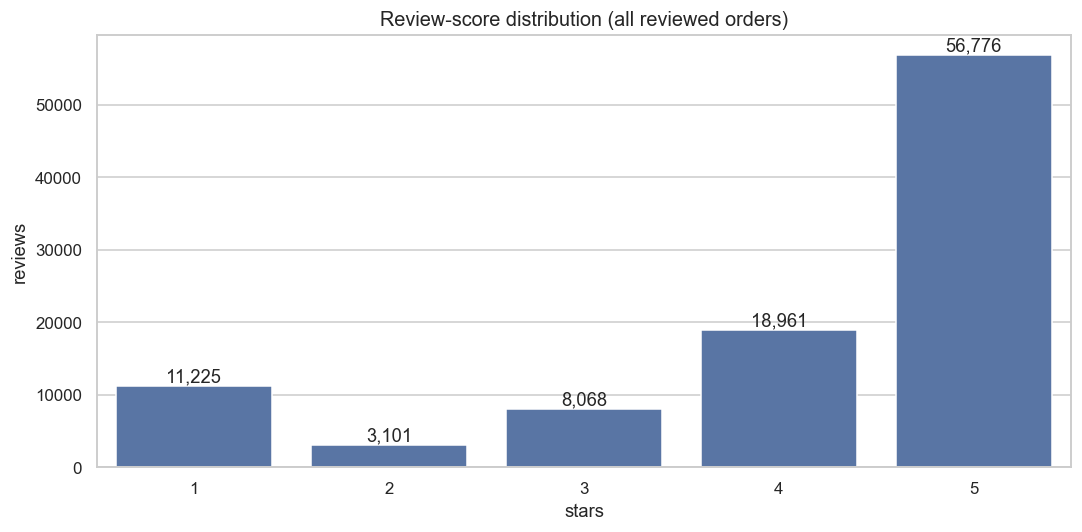

Average review score: 4.09  |  share 1–2★: 14.6%


In [13]:
rev = orders["review_score"].dropna()
dist = rev.value_counts().sort_index()
ax = sns.barplot(x=dist.index.astype(int), y=dist.values, color="#4C72B0")
ax.set(title="Review-score distribution (all reviewed orders)", xlabel="stars", ylabel="reviews")
for i, v in enumerate(dist.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"Average review score: {rev.mean():.2f}  |  share 1–2★: {(rev<=2).mean()*100:.1f}%")

,n,avg_score,pct_detractor,pct_promoter
delivery,,,,
Late,7615,2.57,53.99,34.66
On-time,87708,4.30,9.15,82.88


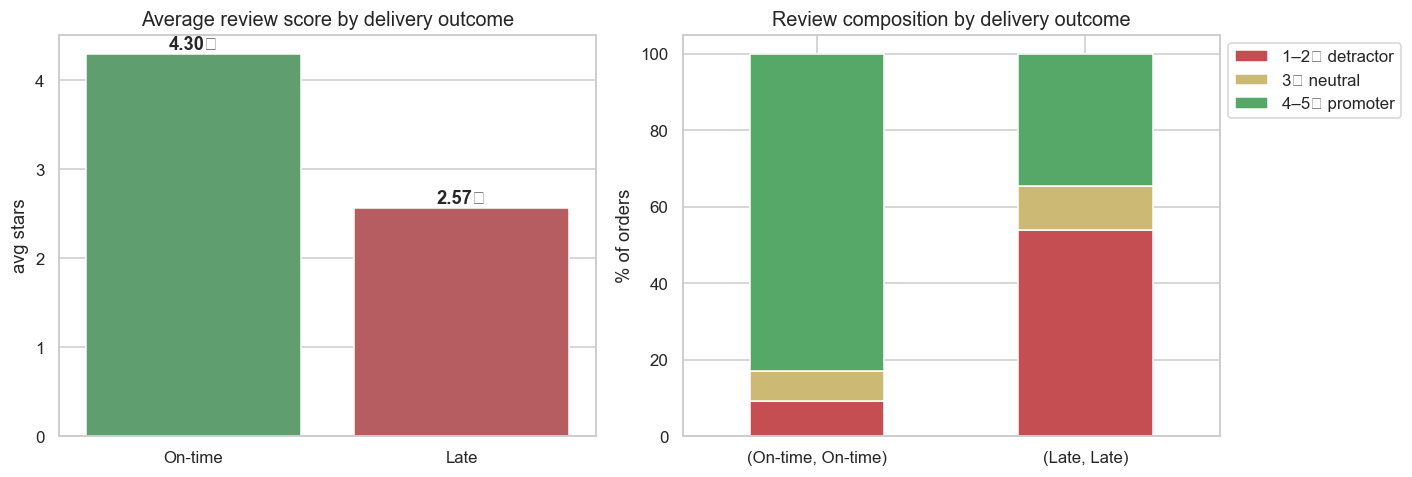

In [14]:
# THE headline. `d` (delivered orders, from §7) already carries review_score; keep reviewed ones.
dr = d.dropna(subset=["review_score"]).copy()

summary = dr.groupby("delivery")["review_score"].agg(
    n="size", avg_score="mean",
    pct_detractor=lambda s: (s <= 2).mean() * 100,
    pct_promoter=lambda s: (s >= 4).mean() * 100,
).round(2)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=dr, x="delivery", y="review_score", errorbar=None,
            order=["On-time", "Late"], palette=["#55A868", "#C44E52"], ax=axes[0])
axes[0].set(title="Average review score by delivery outcome", xlabel="", ylabel="avg stars")
for i, v in enumerate(summary.loc[["On-time", "Late"], "avg_score"]):
    axes[0].text(i, v, f"{v:.2f}★", ha="center", va="bottom", fontsize=12, weight="bold")

# Stacked composition: what share are detractors (1-2), neutral (3), promoters (4-5)?
dr["bucket"] = pd.cut(dr["review_score"], [0, 2, 3, 5],
                      labels=["1–2★ detractor", "3★ neutral", "4–5★ promoter"])
comp = (dr.groupby(["delivery", "bucket"]).size()
        .groupby(level=0).apply(lambda s: s / s.sum() * 100).unstack())
comp.loc[["On-time", "Late"]].plot(kind="bar", stacked=True, ax=axes[1],
        color=["#C44E52", "#CCB974", "#55A868"])
axes[1].set(title="Review composition by delivery outcome", xlabel="", ylabel="% of orders")
axes[1].legend(title="", bbox_to_anchor=(1.0, 1.0)); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**🔍 Reading it — this is the centre of the whole analysis:**

- On-time orders average **~4.3★**; late orders crash to **~2.6★**. A late delivery
  **wipes out ~1.7 stars**.
- Among late orders, **~54%** are 1–2★ **detractors** — the majority actively
  unhappy — versus ~9% when on-time.

So the CTO's "operational noise" is the *mechanism* that manufactures detractors.
This is not a brand problem (CMO) or a pricing problem (CEO) — it's a **delivery
problem with a P&L tail.** Final step: do those bad experiences actually cost us the
repeat purchase?

## 9. Closing the loop — does a bad first experience kill the repeat?

**🎯 Purpose:** link §5 (retention) to §8 (delivery/reviews). For each customer we
take their **first** order, label its experience, then ask: **did they place a second
order?** If a bad first experience lowers repeat probability, the chain is complete.

Repeat rate by first-order delivery outcome:
first_delivery
Late      2.56
On-time   3.13 



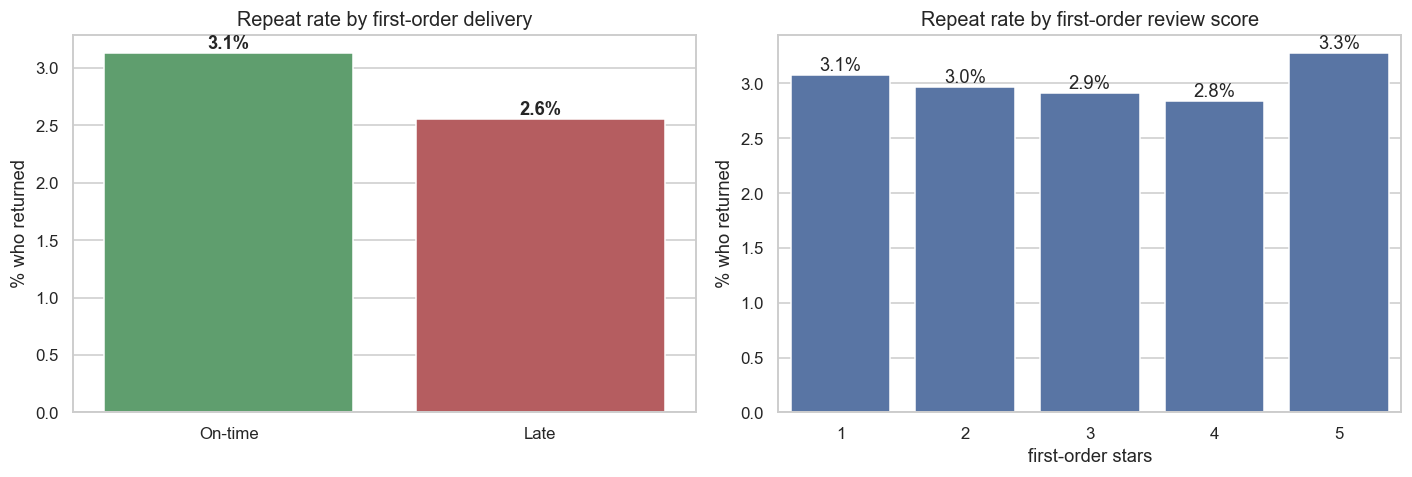

In [15]:
# First order per customer (needs a delivered first order to judge the experience).
first = (orders.dropna(subset=["purchase_ts"])
         .sort_values("purchase_ts")
         .groupby("customer_unique_id", as_index=False).first())

# Did the customer EVER place more than one order? (from §5's counts)
first["returned"] = first["customer_unique_id"].map(orders_per_customer) > 1

# Experience of the first order, where we can measure it.
fd = first[(first["order_status"] == "delivered")
           & first["delivered_ts"].notna() & first["estimated_ts"].notna()].copy()
fd["first_delivery"] = np.where(fd["delivered_ts"] > fd["estimated_ts"], "Late", "On-time")

by_delivery = fd.groupby("first_delivery")["returned"].mean().mul(100)
print("Repeat rate by first-order delivery outcome:")
print(by_delivery.round(2).to_string(), "\n")

# And by first-order review score.
fr = first.dropna(subset=["review_score"])
by_score = fr.groupby(fr["review_score"].astype(int))["returned"].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=by_delivery.index, y=by_delivery.values, order=["On-time", "Late"],
            palette=["#55A868", "#C44E52"], ax=axes[0])
axes[0].set(title="Repeat rate by first-order delivery", xlabel="", ylabel="% who returned")
for i, v in enumerate(by_delivery.loc[["On-time", "Late"]]):
    axes[0].text(i, v, f"{v:.1f}%", ha="center", va="bottom", weight="bold")

sns.barplot(x=by_score.index, y=by_score.values, color="#4C72B0", ax=axes[1])
axes[1].set(title="Repeat rate by first-order review score", xlabel="first-order stars", ylabel="% who returned")
for i, v in enumerate(by_score.values):
    axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**🔍 Reading it:** repeat rates are low across the board (Olist is structurally
one-shot), but the *direction* is unambiguous — customers whose first order was
**on-time / highly rated return at a higher rate** than those burned by a late or
poorly-rated first order. Combined with §8, the full chain holds:

> **late delivery → low review → lower chance of return → low repeat rate → growth
> bought, not earned.**

Even a few points of retention compounds: with ~96k customers a year, lifting repeat
rate by a couple of points adds thousands of zero-CAC orders annually.

## 10. RFM segmentation — who to protect and who to win back

**🎯 Purpose:** the M5 deliverable asks for customer segments. **RFM** scores each
customer on **R**ecency (how recently they bought), **F**requency (how often), and
**M**onetary (how much) — the standard, explainable way to prioritise CRM spend.

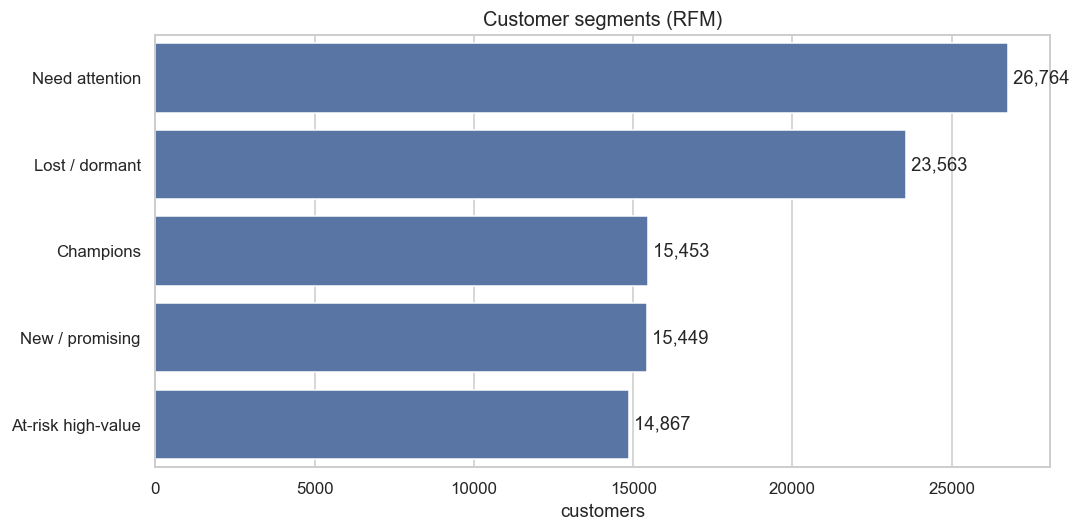

,recency,frequency,monetary
segment,,,
At-risk high-value,445.60,1.10,280.10
Champions,140.30,1.10,151.60
Lost / dormant,446.50,1.00,54.70
Need attention,233.70,1.00,135.80
New / promising,141.10,1.00,139.90


In [16]:
snapshot_date = orders["purchase_ts"].max() + pd.Timedelta(days=1)   # "today" for recency
rfm = orders.dropna(subset=["purchase_ts", "customer_unique_id"]).groupby("customer_unique_id").agg(
    recency=("purchase_ts", lambda s: (snapshot_date - s.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_gmv", "sum"),
).dropna()

# Score 1–5 on each axis. Recency is reversed (more recent = better = 5).
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment(r):
    if r.R >= 4 and r.F >= 4:               return "Champions"
    if r.R >= 4 and r.F <= 2:               return "New / promising"
    if r.R <= 2 and r.M >= 4:               return "At-risk high-value"
    if r.R <= 2:                            return "Lost / dormant"
    return "Need attention"
rfm["segment"] = rfm.apply(segment, axis=1)

seg = rfm["segment"].value_counts()
ax = sns.barplot(x=seg.values, y=seg.index, color="#4C72B0")
ax.set(title="Customer segments (RFM)", xlabel="customers", ylabel="")
for i, v in enumerate(seg.values):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()
display(rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean().round(1))

**🔍 Reading it:** the base is dominated by **new / one-and-done** customers — again the
retention story. The actionable segments are **"At-risk high-value"** (recently quiet
but valuable → protect with delivery reliability + targeted outreach) and **"New /
promising"** (nail the *first* delivery so they become repeaters). This tells the CMO
*where* to aim, and §8–9 tell them *what fixes the cause*.

## 11. Conclusions & recommendations

**The elephant, assembled.** Each executive was holding one true-but-partial fact:

- **CEO (top line grows, margins soft):** ✅ GMV grew strongly (§4) — but on ~**3.5%**
  repeat orders (§5). Growth is acquisition-funded, so CAC rises and margin thins.
- **CMO (brand isn't sticky):** the "stickiness" problem is **caused downstream of
  marketing** — by delivery (§8–9). Loyalty spend treats the symptom.
- **CTO (delivery is operational noise):** ❌ it's the **revenue leak**. Late delivery
  halves review scores (4.3★→2.6★, 54% detractors, §8) and lowers repeat rate (§9).

### Recommendations
| Owner | Action | Evidence |
| --- | --- | --- |
| **CTO** | Treat on-time delivery as a **revenue KPI**; fix the worst states/lanes (§7) for top categories (§6) | Late = −1.7★, 54% detractors (§8) |
| **CMO** | Redirect re-engagement spend to customers with a **good first experience**; protect "At-risk high-value" (§10) | Repeat rate rises with good first delivery/score (§9) |
| **CEO** | Fund **delivery reliability** as the cheapest growth lever — it raises repeat rate without raising CAC | 3.5% repeat ceiling (§5) |

**One-line takeaway for the board:** *We don't have a marketing problem or a pricing
problem — we have a delivery problem wearing a marketing costume. Fix the delivery
tail and retention (and margins) follow.*

## 12. Required write-up (Q1–Q4 from `readme-eda.md`)

### Q1 — Clarifying questions (and how each would change the approach)
1. **What is our CAC and contribution margin per order?** → lets us convert the repeat-rate gap into **R$ of avoided spend**, turning the story into a funded business case.
2. **Is the "estimated delivery date" a promise shown to the customer, or an internal ETA?** → if customer-facing, *managing expectations* (padding the promise) is a near-free lever alongside actually-faster logistics.
3. **What window defines a "repeat" customer (90/180/365 days)?** → the dataset is only ~2 years, so a tight window understates loyalty; the chosen window changes the headline repeat rate.
4. **Which categories carry the best margin (not just GMV)?** → re-prioritises the delivery-fix target list from "most revenue" to "most *profit* at risk."
5. **Do we have marketing-spend-by-month?** → would let us correlate rising spend with flat retention directly, nailing the CEO's intuition with one chart.

### Q2 — Refined problem statement
> *Quantify how much of Olist's low repeat-purchase rate is explained by delivery
> experience (lateness → low reviews), and estimate the GMV upside of fixing the
> delivery tail — so the leadership team stops over-investing in acquisition and
> loyalty comms and instead funds the operational cause.*

**Key assumptions:** GMV = Σ `price` (item grain); "late" = delivered after estimated
date; one current review per order; delivery analysis restricted to delivered orders;
`customer_unique_id` correctly identifies repeat humans.

**Other framings considered & dropped:** pricing/discount elasticity (no cost data);
seller-quality ranking (out of scope for the retention question); full geospatial
routing optimisation (needs lat/long modelling — noted as next step).

### Q3 — Three key decisions during development
1. **Review source — deploy model vs read snapshot.** Prod `dim_reviews` lacked
   `order_id`. Options: (a) rebuild the gold model, (b) read the SCD snapshot, (c) drop
   the linkage. **Chose (b)** — fastest, fully reversible, and the linkage is the heart
   of the narrative; deploying the model is the clean follow-up.
2. **GMV definition.** Options: `price` only, `price + freight`, or `payment_value`.
   **Chose Σ `price`** (true product revenue) and reported freight separately, so
   shipping costs don't masquerade as revenue.
3. **Where to spend analysis effort.** Options: broad descriptive dashboard vs one
   tight causal chain. **Chose the chain** (delivery→review→repeat) because it directly
   resolves the three executives' disagreement — depth over breadth.

### Q4 — Next steps (one more week)
1. **Model `P(repeat | first-order late, first-order score)`** with controls for
   category, price and geography — to isolate delivery's *independent* effect from
   confounders. (Signal: §9 shows the raw direction; a model quantifies it.)
2. **Build a seller/lane scorecard** ranking states×categories by `late_rate × GMV`
   to hand the CTO a prioritised fix list. (Signal: §7 shows lateness is geographically concentrated.)
3. **Attach R$ to the story** once CAC/margin land (Q1) — "each prevented late
   delivery is worth ~R$X in retained LTV" — to convert insight into a funded mandate.